# Task 2: Unemployment Analysis with Python

## Objective

Analyze unemployment trends in India using exploratory data analysis to identify regional and temporal patterns and examine the impact of the COVID-19 pandemic on unemployment rates.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set visualization style
sns.set_style("whitegrid")

# Display all columns when viewing DataFrames
pd.set_option("display.max_columns", None)

In [2]:
# Load the unemployment dataset

df = pd.read_csv("Unemployment in India.csv")


In [3]:
# Check number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (768, 7)


In [4]:
# Display first five rows

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Display column names

print(df.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [7]:
for col in df.columns:
    print(repr(col))

'Region'
' Date'
' Frequency'
' Estimated Unemployment Rate (%)'
' Estimated Employed'
' Estimated Labour Participation Rate (%)'
'Area'


In [8]:
# Remove leading and trailing spaces from column names

df.columns = df.columns.str.strip()

# Check cleaned column names
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [9]:
# Rename columns for easier analysis

df = df.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate"
})

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed', 'Labour_Participation_Rate', 'Area']


In [10]:
# Remove completely empty rows

df = df.dropna(how="all")

print("Shape after removing empty rows:", df.shape)

Shape after removing empty rows: (740, 7)


In [11]:
# Remove unnecessary spaces from text values

for column in df.select_dtypes(include=["object","str"]).columns:
    df[column] = df[column].str.strip()

In [12]:
# Convert Date column to datetime

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

print(df.dtypes)

Region                                  str
Date                         datetime64[us]
Frequency                               str
Unemployment_Rate                   float64
Employed                            float64
Labour_Participation_Rate           float64
Area                                    str
dtype: object


In [13]:
# Check missing values

df.isnull().sum()


Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
dtype: int64

In [14]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [15]:
# Display dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display first 5 rows
df.head()

Number of rows: 740
Number of columns: 7


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [16]:
# Check data types
df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Region                     740 non-null    str           
 1   Date                       740 non-null    datetime64[us]
 2   Frequency                  740 non-null    str           
 3   Unemployment_Rate          740 non-null    float64       
 4   Employed                   740 non-null    float64       
 5   Labour_Participation_Rate  740 non-null    float64       
 6   Area                       740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 61.8 KB


In [17]:
# Statistical summary
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [18]:
# Number of unique regions

print("Number of regions:", df["Region"].nunique())

Number of regions: 28


In [19]:
# Display all regions

print(sorted(df["Region"].unique()))

['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [20]:
# Display unique area categories

print(df["Area"].unique())

<ArrowStringArray>
['Rural', 'Urban']
Length: 2, dtype: str


In [21]:
# Count observations in each area

df["Area"].value_counts()

Area
Urban    381
Rural    359
Name: count, dtype: int64

In [22]:
# Find the earliest and latest dates

print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Start Date: 2019-05-31 00:00:00
End Date: 2020-06-30 00:00:00


### Dataset Time Period

The dataset covers the period from May 2019 to June 2020. Therefore, it contains both pre-COVID observations and observations from the initial COVID-19 period in India, but it does not contain sufficient post-COVID data.

For this reason, the COVID analysis will compare:

- Pre-COVID: May 2019 to February 2020
- COVID Period: March 2020 to June 2020

In [23]:
# Extract year and month information

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,September


In [24]:
# Calculate average unemployment rate by region

region_avg = (
    df.groupby("Region")["Unemployment_Rate"]
      .mean()
      .sort_values(ascending=False)
)

region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Unemployment_Rate, dtype: float64

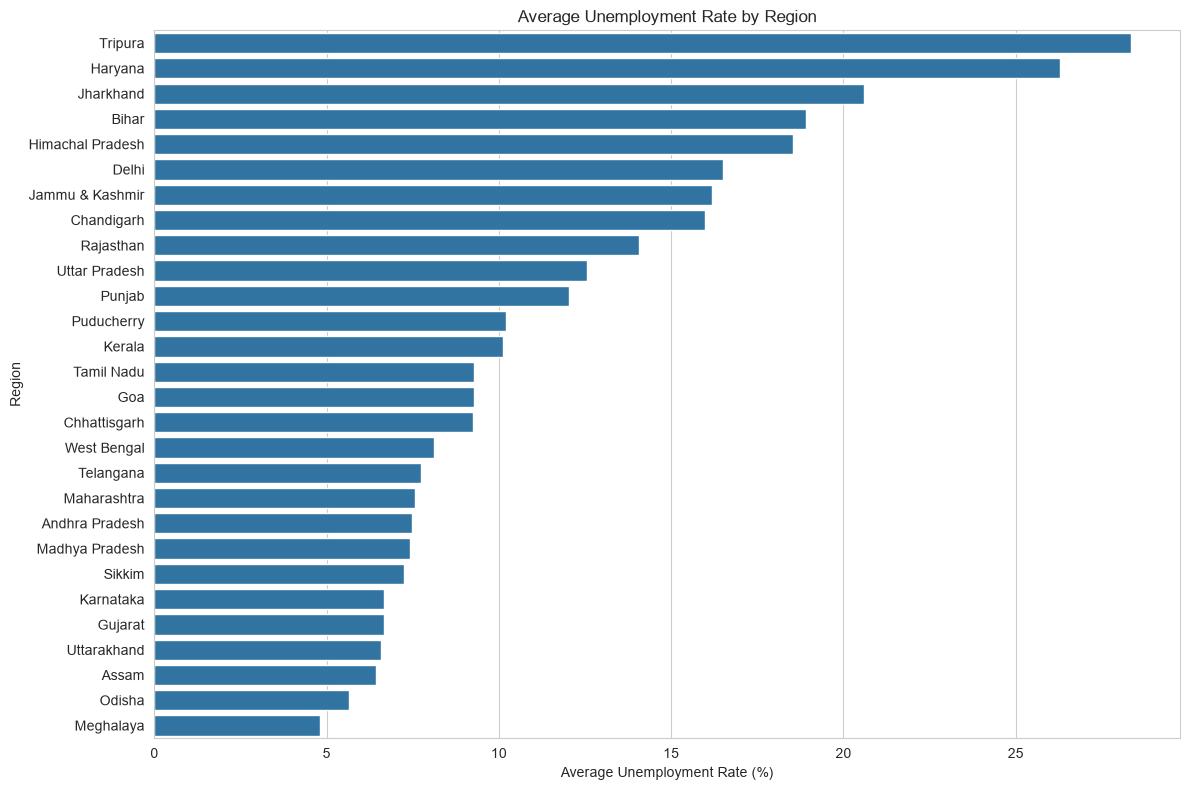

In [25]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=region_avg.values,
    y=region_avg.index
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.savefig(f"screenshots/region_unemployment.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The average unemployment rate varies considerably across regions. Some regions experience substantially higher unemployment rates than others, indicating significant geographical differences in employment conditions across India.

In [26]:
# Calculate average unemployment rate by area

area_avg = (
    df.groupby("Area")["Unemployment_Rate"]
      .mean()
      .sort_values(ascending=False)
)

area_avg

Area
Urban    13.166614
Rural    10.324791
Name: Unemployment_Rate, dtype: float64

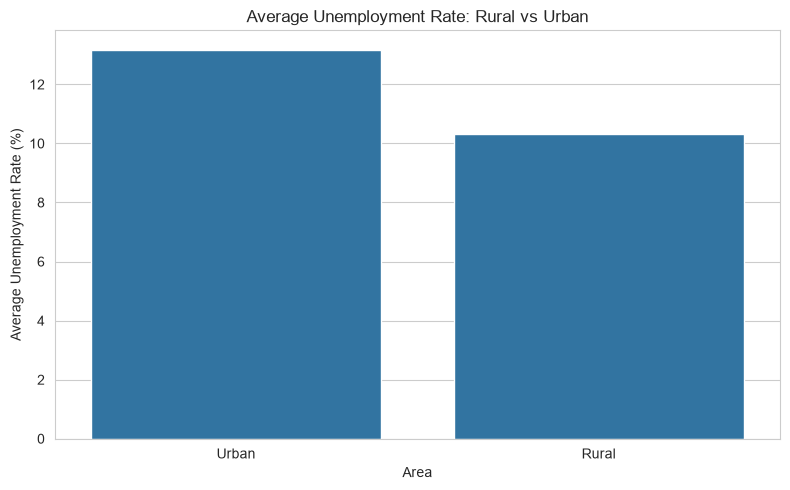

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=area_avg.index,
    y=area_avg.values
)

plt.title("Average Unemployment Rate: Rural vs Urban")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.savefig(f"screenshots/rural_vs_urban.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The average unemployment rate differs between rural and urban areas. This indicates that labour-market conditions were not identical across these areas, potentially reflecting differences in industries, occupations, and employment opportunities.

In [28]:
# Calculate average unemployment rate by month

monthly_avg = (
    df.groupby("Month_Name")["Unemployment_Rate"]
      .mean()
)

# Arrange months chronologically
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_avg = monthly_avg.reindex(month_order)

monthly_avg

Month_Name
January       9.950755
February      9.964717
March        10.700577
April        23.641569
May          16.646190
June         10.553462
July          9.033889
August        9.637925
September     9.051731
October       9.900909
November      9.868364
December      9.497358
Name: Unemployment_Rate, dtype: float64

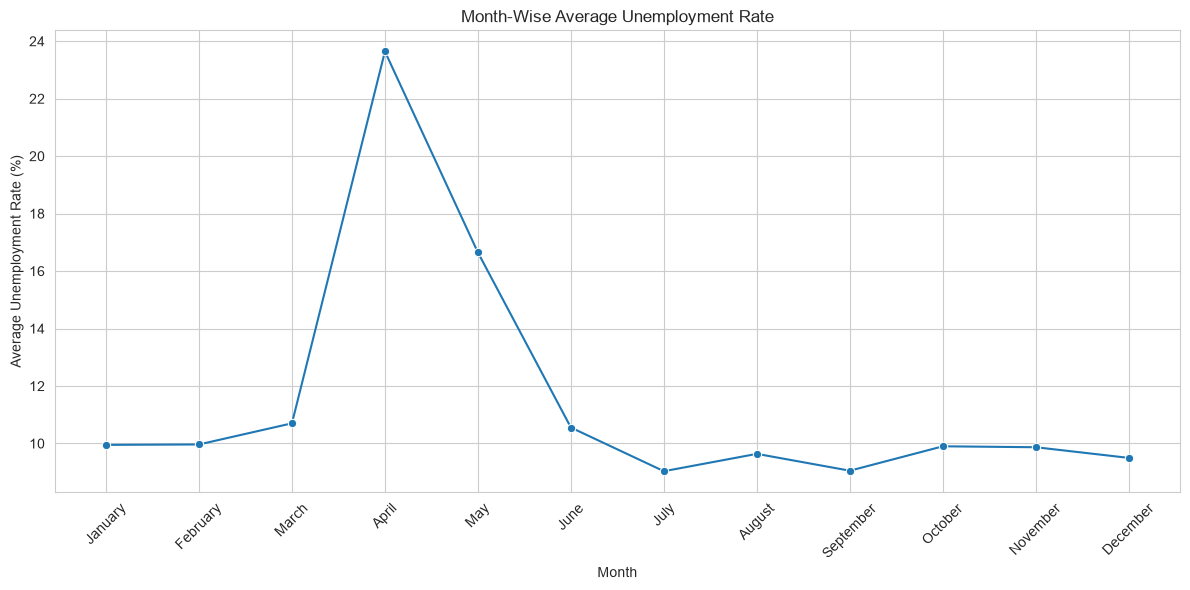

In [29]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_avg.index,
    y=monthly_avg.values,
    marker="o"
)

plt.title("Month-Wise Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(f"screenshots/monthly_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The monthly analysis shows variations in unemployment levels across the available months. The unemployment rate changes noticeably during the period, with particularly significant changes occurring around the beginning of the COVID-19 period.

In [30]:
# Display all available regions

print(sorted(df["Region"].unique()))

['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [31]:
selected_states = [
    "Tamil Nadu",
    "Maharashtra",
    "Karnataka"
]

# Verify that all selected states exist

for state in selected_states:
    print(state, ":", state in df["Region"].unique())

Tamil Nadu : True
Maharashtra : True
Karnataka : True


In [32]:
# Filter data for selected states

state_data = df[
    df["Region"].isin(selected_states)
].copy()

state_data.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Year,Month,Month_Name
147,Karnataka,2019-05-31,Monthly,5.46,13911440.0,46.36,Rural,2019,5,May
148,Karnataka,2019-06-30,Monthly,5.98,12888490.0,43.12,Rural,2019,6,June
149,Karnataka,2019-07-31,Monthly,0.52,12169808.0,38.42,Rural,2019,7,July
150,Karnataka,2019-08-31,Monthly,0.37,12686470.0,39.93,Rural,2019,8,August
151,Karnataka,2019-09-30,Monthly,3.20,13741892.0,44.45,Rural,2019,9,September


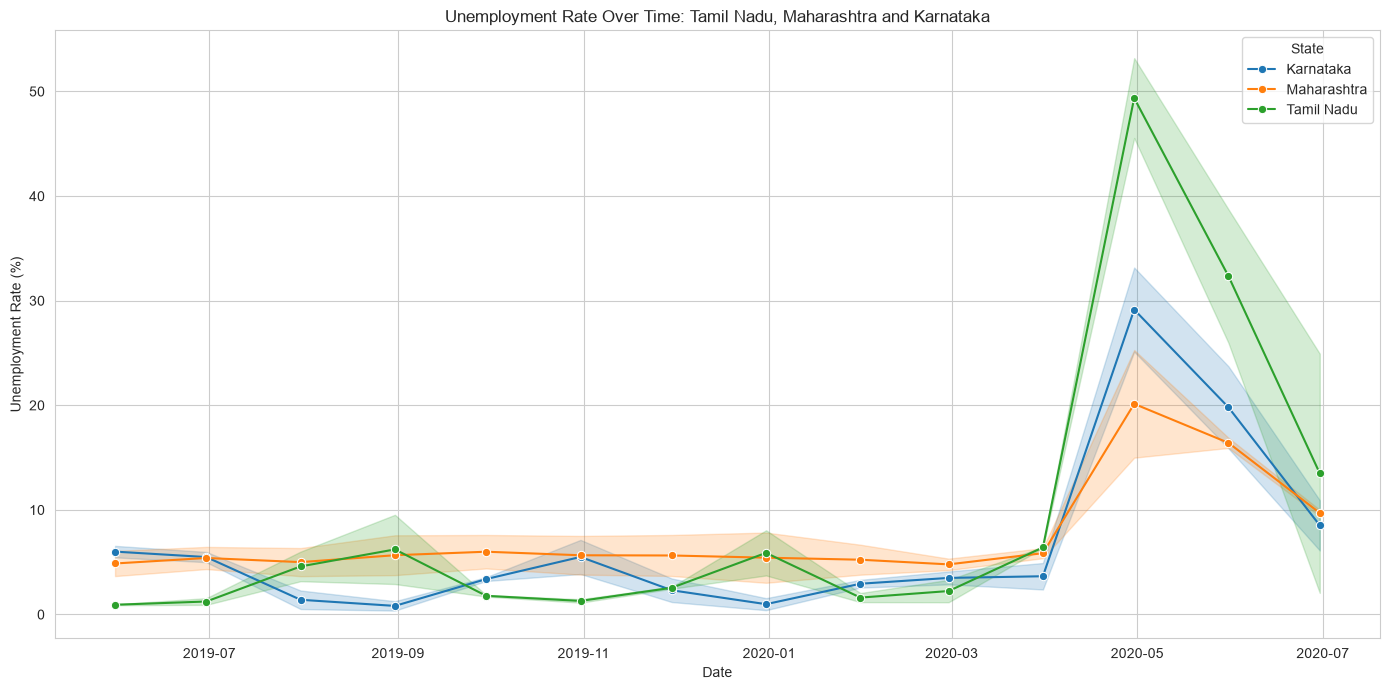

In [33]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=state_data,
    x="Date",
    y="Unemployment_Rate",
    hue="Region",
    marker="o"
)

plt.title(
    "Unemployment Rate Over Time: Tamil Nadu, Maharashtra and Karnataka"
)

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend(title="State")

plt.tight_layout()
plt.savefig(f"screenshots/state_time_series.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The time-series analysis shows that unemployment rates varied across Tamil Nadu, Maharashtra, and Karnataka throughout the study period. The states experienced different levels of fluctuation, with noticeable changes during the COVID-19 period. This indicates that the pandemic's impact on unemployment was not uniform across all states.

In [34]:
# Calculate average unemployment rate for each region

state_avg = (
    df.groupby("Region")["Unemployment_Rate"]
      .mean()
      .sort_values(ascending=False)
)

# Select top 10

top_10_states = state_avg.head(10)

top_10_states

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Unemployment_Rate, dtype: float64

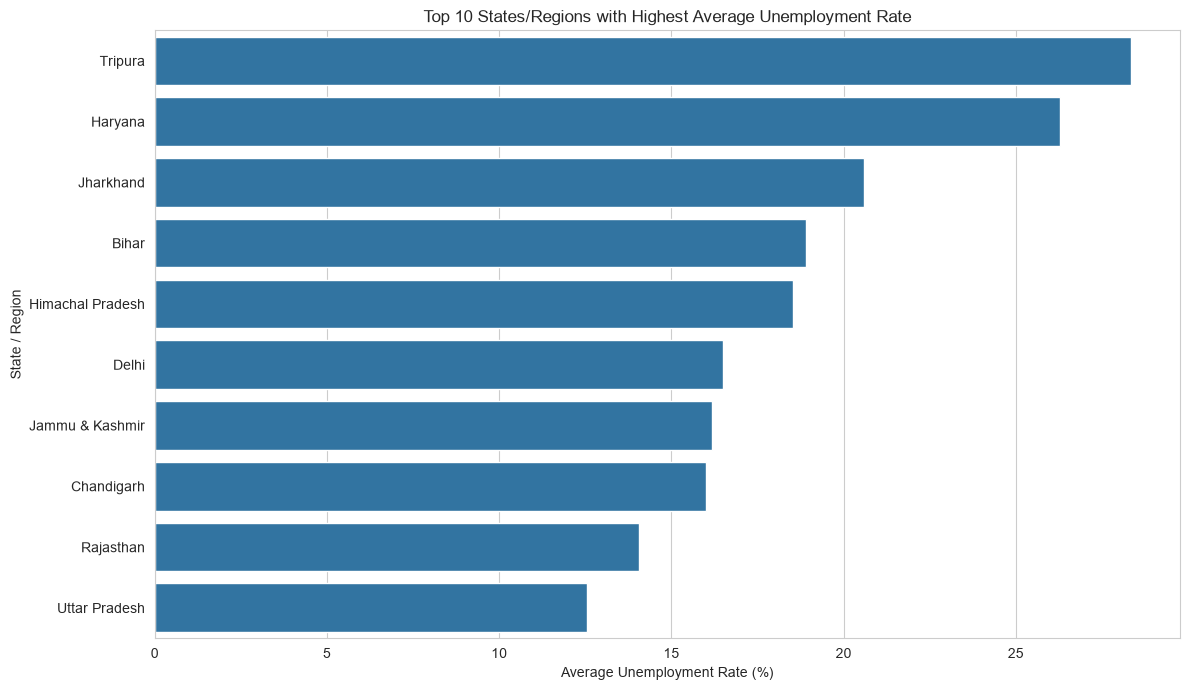

In [35]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_10_states.values,
    y=top_10_states.index
)

plt.title("Top 10 States/Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State / Region")

plt.tight_layout()
plt.savefig(f"screenshots/top_10_regions.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The top 10 regions with the highest average unemployment rates are identified in the chart. The results demonstrate significant regional differences in unemployment during the study period.

In [36]:
# Select variables for correlation analysis

correlation_data = df[
    [
        "Unemployment_Rate",
        "Employed",
        "Labour_Participation_Rate"
    ]
]

# Calculate correlation matrix

correlation_matrix = correlation_data.corr()

correlation_matrix

,Unemployment_Rate,Employed,Labour_Participation_Rate
Unemployment_Rate,1.000000,-0.222876,0.002558
Employed,-0.222876,1.000000,0.011300
Labour_Participation_Rate,0.002558,0.011300,1.000000


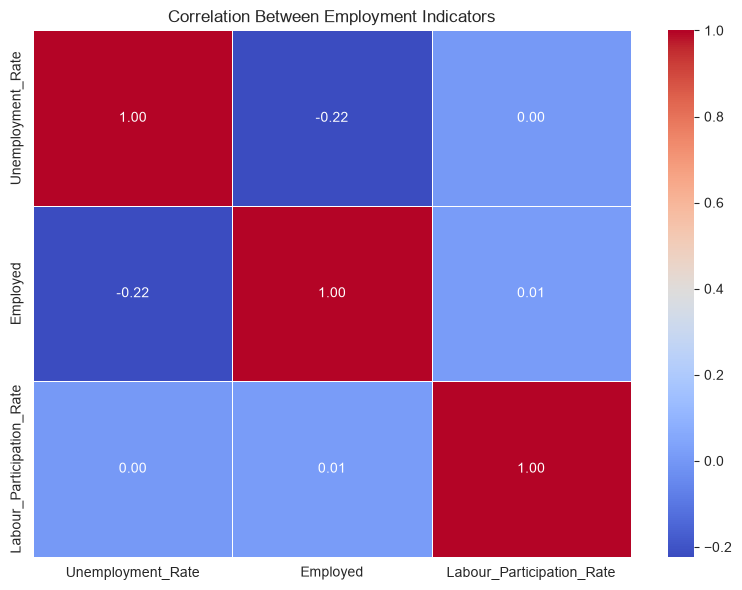

In [37]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Employment Indicators")

plt.tight_layout()
plt.savefig(f"screenshots/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The correlation heatmap shows the strength and direction of the relationships between unemployment rate, employment, and labour participation rate. Positive values indicate that two variables tend to increase together, while negative values indicate an inverse relationship. Correlation represents association and should not be interpreted as proof of causation.

In [38]:
# Define COVID-19 analysis period

covid_start = pd.Timestamp("2020-03-01")

df["Period"] = np.where(
    df["Date"] < covid_start,
    "Pre-COVID",
    "COVID Period"
)

df[["Date", "Period"]].head()

,Date,Period
0,2019-05-31,Pre-COVID
1,2019-06-30,Pre-COVID
2,2019-07-31,Pre-COVID
3,2019-08-31,Pre-COVID
4,2019-09-30,Pre-COVID


In [39]:
df["Period"].value_counts()

Period
Pre-COVID       536
COVID Period    204
Name: count, dtype: int64

In [40]:
# Calculate mean labour-market indicators for each period

period_comparison = (
    df.groupby("Period")[
        [
            "Unemployment_Rate",
            "Employed",
            "Labour_Participation_Rate"
        ]
    ]
    .mean()
)

period_comparison

,Unemployment_Rate,Employed,Labour_Participation_Rate
Period,,,
COVID Period,17.774363,6.517203e+06,39.330049
Pre-COVID,9.509534,7.466028e+06,43.886119


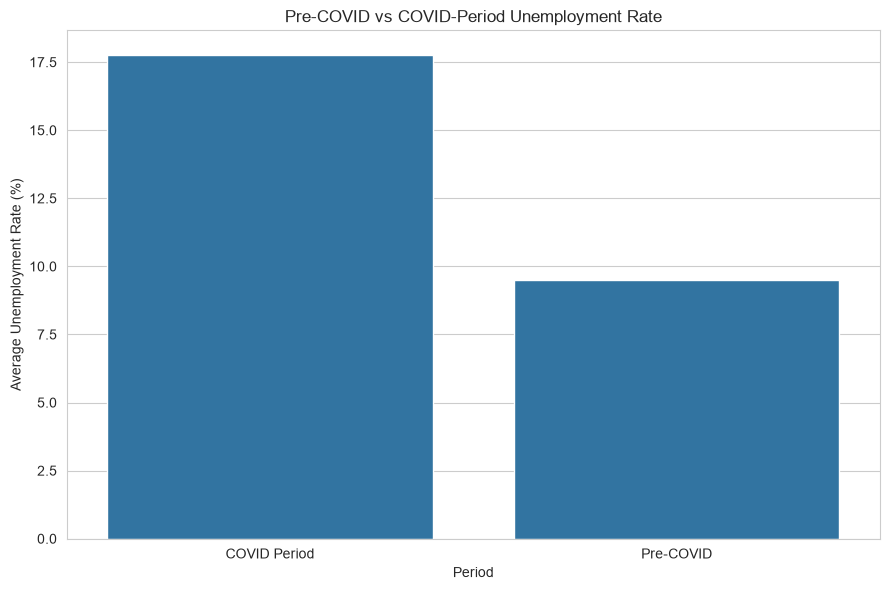

In [41]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=period_comparison.reset_index(),
    x="Period",
    y="Unemployment_Rate"
)

plt.title("Pre-COVID vs COVID-Period Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.savefig(f"screenshots/covid_unemployment.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The comparison between the pre-COVID and COVID periods shows a substantial change in unemployment conditions. The COVID-19 pandemic disrupted economic activities and employment opportunities, resulting in a significant change in the unemployment rate during the initial pandemic period.

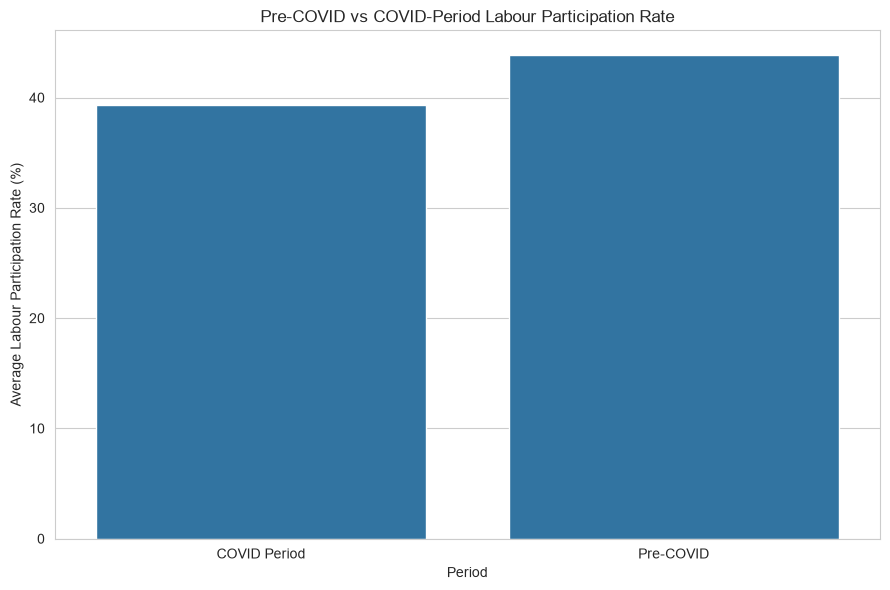

In [42]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=period_comparison.reset_index(),
    x="Period",
    y="Labour_Participation_Rate"
)

plt.title("Pre-COVID vs COVID-Period Labour Participation Rate")
plt.xlabel("Period")
plt.ylabel("Average Labour Participation Rate (%)")

plt.tight_layout()
plt.savefig(f"screenshots/covid_labour_participation.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The labour participation rate also changed between the pre-COVID and COVID periods. The change indicates that the pandemic affected not only unemployment but also participation in the labour market.

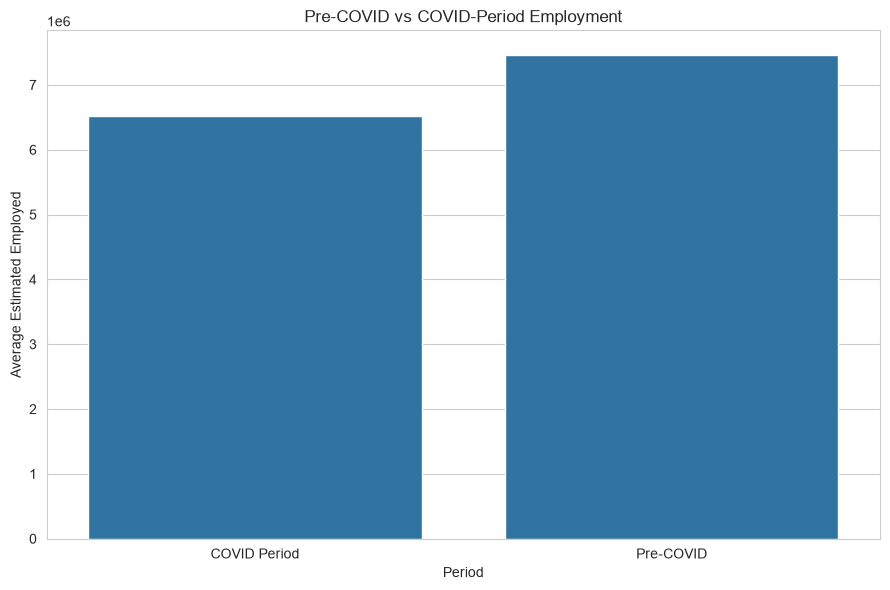

In [43]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=period_comparison.reset_index(),
    x="Period",
    y="Employed"
)

plt.title("Pre-COVID vs COVID-Period Employment")
plt.xlabel("Period")
plt.ylabel("Average Estimated Employed")

plt.tight_layout()
plt.savefig(f"screenshots/covid_employment.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The comparison of estimated employment between the two periods highlights changes in employment conditions during the initial COVID-19 period. The disruption to economic activity affected employment levels across the regions represented in the dataset.

# Key Findings

* Unemployment rates varied significantly across different regions of India. Tripura recorded the highest average unemployment rate at approximately **28.35%**, while Meghalaya recorded the lowest at approximately **4.80%**.

* Urban areas had a higher average unemployment rate (**13.17%**) compared with rural areas (**10.32%**).

* Monthly analysis showed a major increase in unemployment during **April**, when the average unemployment rate reached approximately **23.64%**.

* The unemployment trends of Tamil Nadu, Karnataka, and Maharashtra showed a sharp increase during the COVID-19 period. Tamil Nadu experienced the largest visible spike among these three states.

* The top 10 analysis identified Tripura, Haryana, Jharkhand, Bihar, and Himachal Pradesh among the regions with the highest average unemployment rates.

* The correlation analysis showed a **weak negative relationship (-0.22)** between unemployment rate and estimated employment.

* The average unemployment rate increased from approximately **9.51% before COVID-19 to 17.77% during the COVID period**.

* The average labour participation rate decreased from approximately **43.89% to 39.33%** during the COVID period.

* Average estimated employment decreased from approximately **7.47 million to 6.52 million** during the COVID period.

* Overall, the analysis indicates that the COVID-19 period was associated with a significant deterioration in employment conditions, although the impact varied across different regions and states.


# Conclusion

This project analyzed unemployment and employment patterns in India using Python, Pandas, Matplotlib, and Seaborn.

The analysis examined regional differences, rural and urban unemployment, monthly trends, state-level unemployment patterns, employment indicators, correlations, and changes during the COVID-19 period.

The results show considerable variation in unemployment across Indian regions. Urban areas recorded a higher average unemployment rate than rural areas, while some regions such as Tripura and Haryana experienced considerably higher unemployment than others.

A major change was observed during the COVID-19 period. The average unemployment rate increased from approximately **9.51% to 17.77%**, while labour participation decreased from approximately **43.89% to 39.33%**. Estimated employment also decreased from approximately **7.47 million to 6.52 million**.

The state-level analysis further demonstrated that the impact was not uniform across India. Tamil Nadu, Karnataka, and Maharashtra all experienced significant increases in unemployment during the COVID period, with Tamil Nadu showing the largest visible spike among the three.

Overall, this project demonstrates how Exploratory Data Analysis (EDA) and data visualization can be used to identify regional and temporal patterns and understand major changes in employment conditions.
